<a href="https://colab.research.google.com/github/MuhammadAqsandy/scikit-learn-cookbook/blob/main/chapter_07_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Support Vector Machines and Kernel Methods
## 📌 Summary
SVM mencari **hyperplane optimal** yang memisahkan kelas dengan **maximum margin**. Kernel trick memungkinkan SVM bekerja di ruang fitur yang sangat high-dimensional.

## 🧠 Theoretical Deep-Dive

### 7.1 Hard Margin SVM
Minimize ||w||² subject to yᵢ(w·xᵢ + b) ≥ 1 untuk semua i

Margin = 2/||w||. Support vectors = titik data paling dekat ke hyperplane.

### 7.2 Soft Margin SVM (C-SVM)
Real data tidak selalu linearly separable. Soft margin menambahkan **slack variables** ξᵢ:
Minimize ½||w||² + C·Σξᵢ

**C tradeoff:**
- C besar → narrow margin, sedikit misclassification (risiko overfit)
- C kecil → wider margin, lebih banyak misclassification (risiko underfit)

### 7.3 Kernel Trick
Transform data ke higher-dimensional space tanpa eksplisit menghitung transformasi:
- **Linear**: K(x,z) = x·z
- **RBF/Gaussian**: K(x,z) = exp(-γ||x-z||²)
- **Polynomial**: K(x,z) = (γ·x·z + r)ᵈ
- **Sigmoid**: K(x,z) = tanh(γ·x·z + r)

### 7.4 SVR (Support Vector Regression)
SVR mencari fungsi yang memiliki paling banyak ε deviasi dari target, dengan epsilon-insensitive loss tube.

## 💻 Code Reproduction

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    svc = SVC(kernel=kernel, C=1.0, random_state=42)
    svc.fit(X_train_s, y_train)
    print(f"kernel={kernel:8}: acc={svc.score(X_test_s, y_test):.4f}, n_support={svc.n_support_}")

kernel=linear  : acc=0.9500, n_support=[26 27]
kernel=rbf     : acc=0.9500, n_support=[21 22]
kernel=poly    : acc=0.8833, n_support=[43 43]
kernel=sigmoid : acc=0.8000, n_support=[31 32]


In [3]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=300, n_features=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_, 4))
print("Test accuracy:", round(grid.score(X_test_s, y_test), 4))

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9625
Test accuracy: 1.0


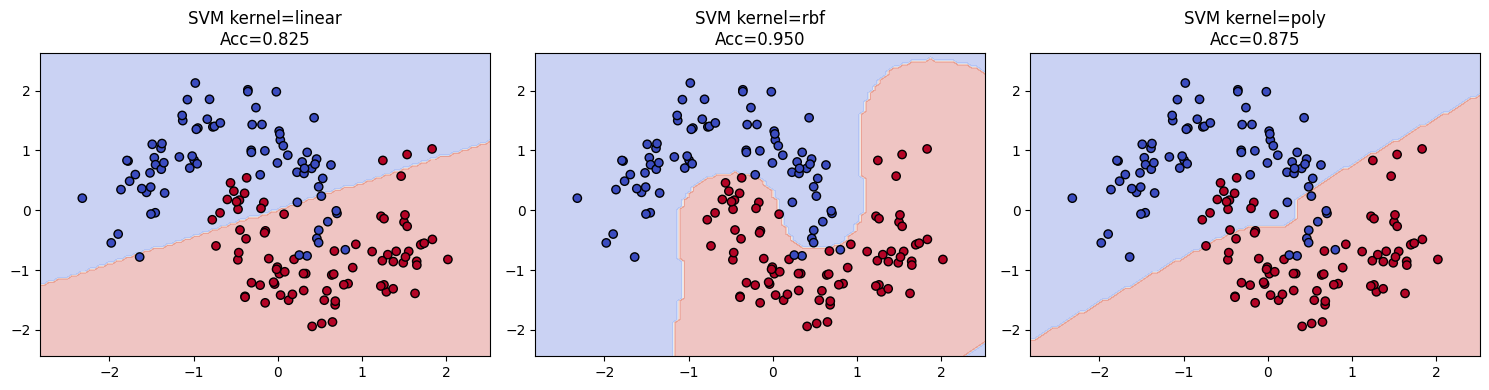

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (kernel, params) in zip(axes, [("linear", {}), ("rbf", {"gamma": 1.0}), ("poly", {"degree": 3})]):
    svc = SVC(kernel=kernel, C=1.0, **params)
    svc.fit(X_train_s, y_train)

    x_min, x_max = X_train_s[:, 0].min()-0.5, X_train_s[:, 0].max()+0.5
    y_min, y_max = X_train_s[:, 1].min()-0.5, X_train_s[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors="k")
    ax.set_title(f"SVM kernel={kernel}\nAcc={svc.score(X_test_s, y_test):.3f}")

plt.tight_layout(); plt.show()

In [5]:
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X, y = make_regression(n_samples=200, n_features=5, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = StandardScaler(); scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

for kernel in ["linear", "rbf", "poly"]:
    svr = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    svr.fit(X_train_s, y_train_s)
    y_pred = scaler_y.inverse_transform(svr.predict(X_test_s).reshape(-1, 1)).ravel()
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"SVR kernel={kernel:8}: R²={r2:.4f}, RMSE={rmse:.2f}")

SVR kernel=linear  : R²=0.9774, RMSE=14.02
SVR kernel=rbf     : R²=0.9100, RMSE=27.96
SVR kernel=poly    : R²=0.6169, RMSE=57.69


In [6]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Multiclass SVM (uses OvO by default)
svc = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
svc.fit(X_train_s, y_train)

print("Accuracy:", svc.score(X_test_s, y_test))
print("n_support per class:", svc.n_support_)
print("\nClassification Report:")
print(classification_report(y_test, svc.predict(X_test_s), target_names=["setosa","versicolor","virginica"]))
print("\nPredicted probabilities (first 3):")
print(svc.predict_proba(X_test_s[:3]).round(3))

Accuracy: 0.9666666666666667
n_support per class: [ 6 14 11]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Predicted probabilities (first 3):
[[0.011 0.96  0.03 ]
 [0.961 0.023 0.016]
 [0.041 0.019 0.94 ]]


## ✅ Chapter Summary
- SVM mencari **maximum margin hyperplane** antara kelas
- **C** mengontrol tradeoff margin-misclassification
- **RBF kernel** adalah default terbaik untuk non-linear data
- **γ (gamma)** mengontrol 'radius pengaruh' satu training example
- Selalu **standardize** sebelum SVM (sangat sensitif skala)
- **GridSearchCV** untuk tuning C dan gamma secara bersamaan
- SVR untuk regression dengan epsilon-insensitive loss